In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/preprocessed_perth.csv")
df

,price,bedrooms,bathrooms,garage,land_area,floor_area,build_year,cbd_dist,nearest_stn_dist,date_sold,postcode,nearest_sch_dist
0,565000,4,2,2.0,600,160,2003.0,18300,1800,09-2018,6164,0.828339
1,365000,3,2,2.0,351,139,2013.0,26900,4900,02-2019,6167,5.524324
2,287000,3,1,1.0,719,86,1979.0,22600,1900,06-2015,6111,1.649178
3,255000,2,1,2.0,651,59,1953.0,17900,3600,07-2018,6056,1.571401
4,325000,4,1,2.0,466,131,1998.0,11200,2000,11-2016,6054,1.514922
...,...,...,...,...,...,...,...,...,...,...,...,...
31163,1040000,4,3,2.0,292,245,2013.0,16100,1500,03-2016,6162,1.430350
31164,410000,3,2,2.0,228,114,1995.0,9600,4600,02-2017,6061,1.679644
31165,427000,3,2,2.0,261,112,1995.0,9600,4600,02-2017,6061,1.669159
31166,295000,3,1,2.0,457,85,1974.0,12600,4400,10-2016,6064,0.358494


In [15]:
from datetime import datetime

df['house_age'] = datetime.now().year - df['build_year']
df['build_year'].describe()

count    31168.000000
mean      1990.437083
std         19.740675
min       1868.000000
25%       1981.000000
50%       1995.000000
75%       2004.000000
max       2017.000000
Name: build_year, dtype: float64

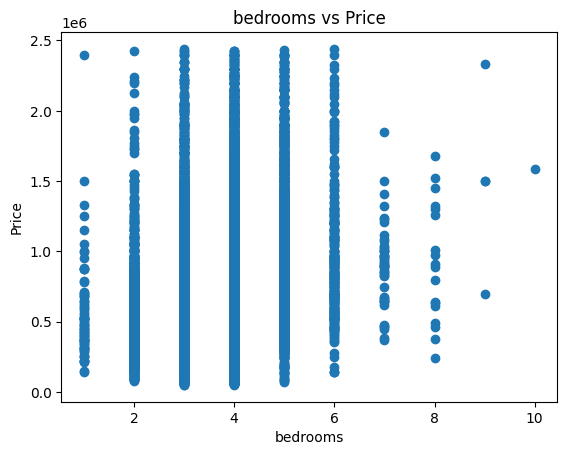

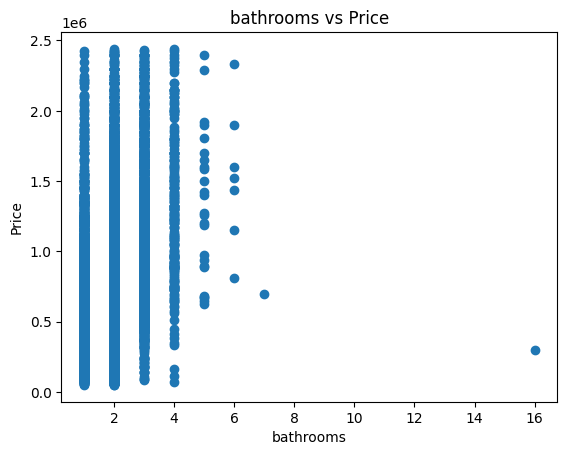

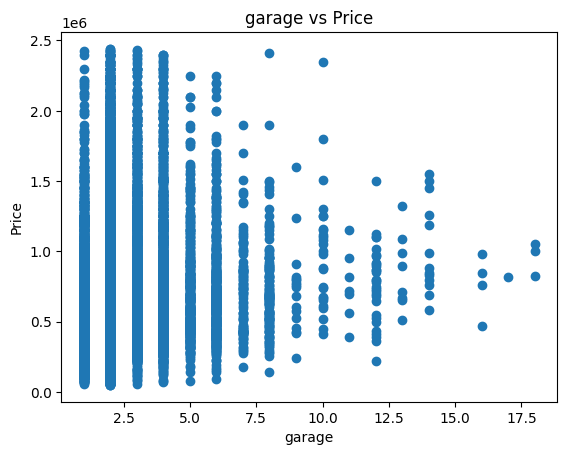

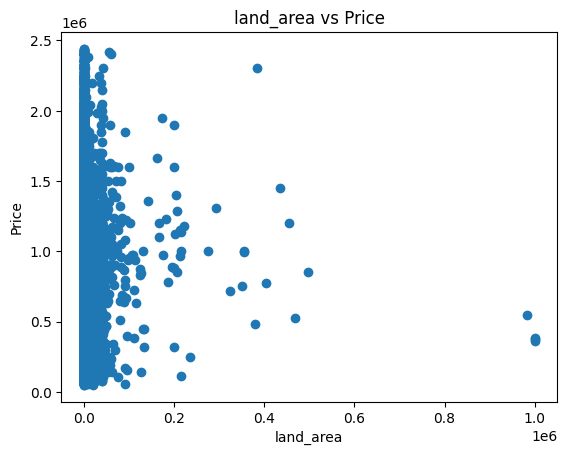

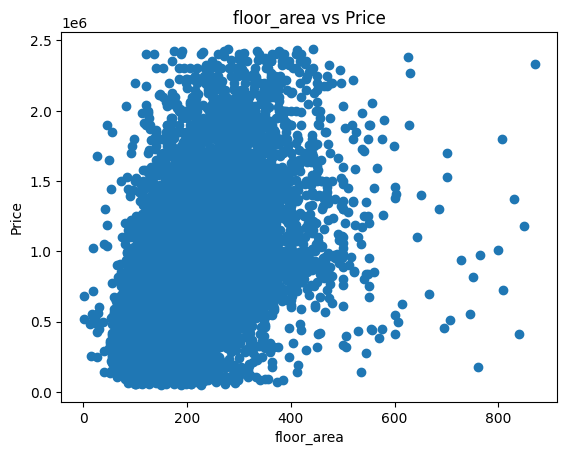

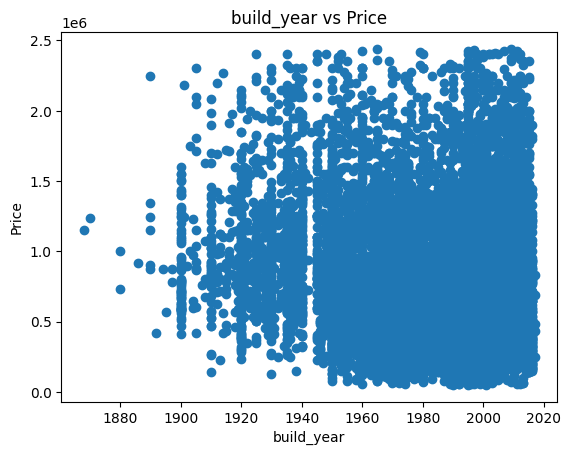

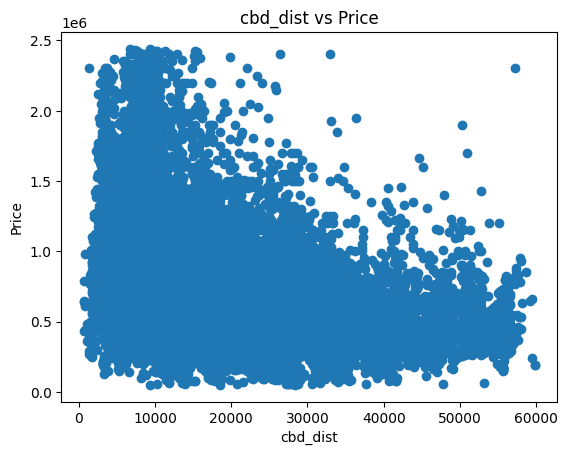

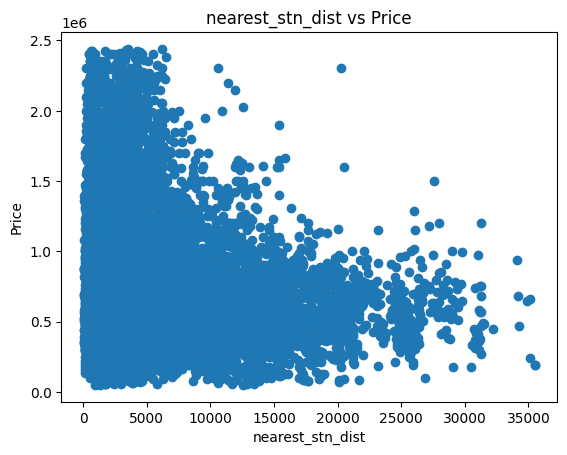

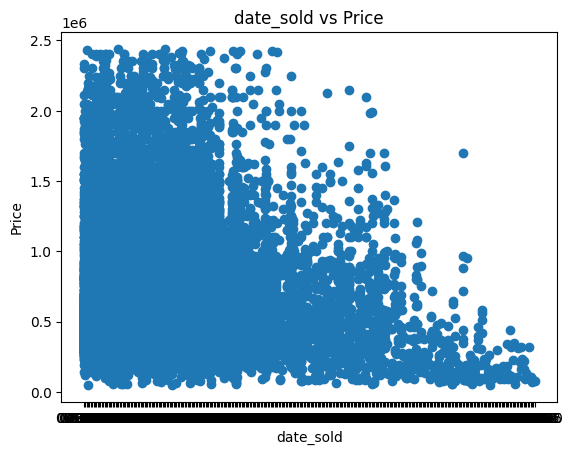

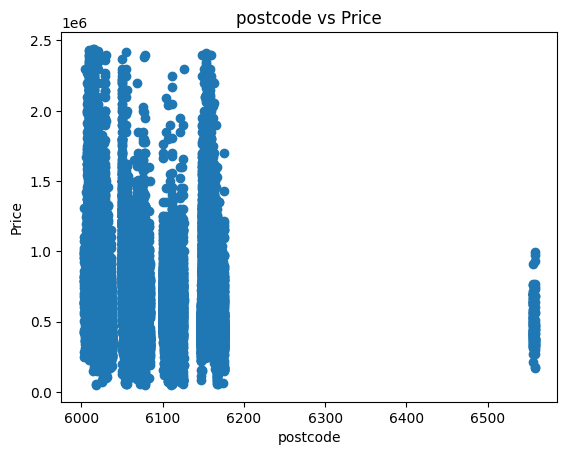

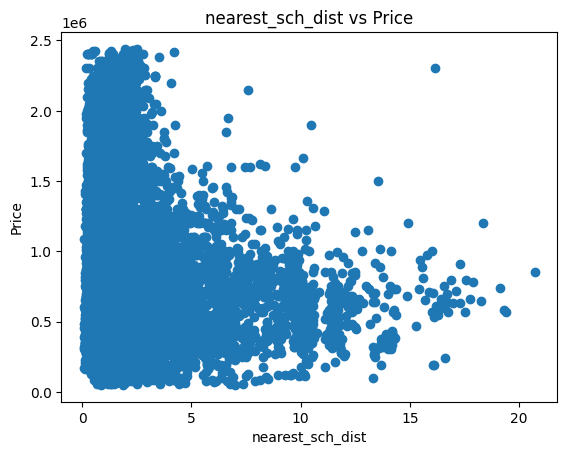

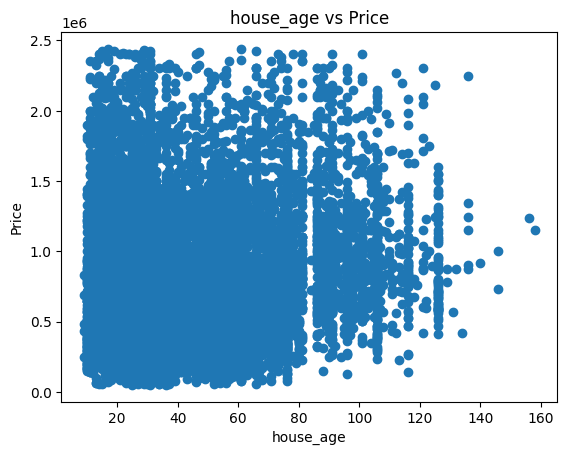

In [35]:
for col in df.columns:
    if col == 'price':
        continue 
    plt.scatter(df[col], df['price'])
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.title(f"{col} vs Price")
    plt.show()

In [ ]:
# Picking floor area for linear regression
df = df[['floor_area', 'price']]
training_df = df.sample(frac=0.8, random_state=42).reset_index(drop=True)
test_df = df.sample(frac=0.2, random_state=42).reset_index(drop=True)

(       floor_area    price
 0             107   450000
 1             226   197000
 2             153   267000
 3             292   780000
 4             166   520000
 ...           ...      ...
 24929         227   600000
 24930         213   398000
 24931         230   685000
 24932         205  1500000
 24933         139   369000
 
 [24934 rows x 2 columns],
       floor_area    price
 0            147  1150000
 1            140   255000
 2            230   500000
 3            250   700000
 4            368  1520000
 ...          ...      ...
 6229         183   805000
 6230         109   416500
 6231         145   455000
 6232          85   302500
 6233         178   462500
 
 [6234 rows x 2 columns])

In [42]:
floor_area_mean = training_df["floor_area"].mean()
price_mean = training_df["price"].mean()

slope = (
    (training_df["floor_area"] - floor_area_mean) * (training_df["price"] - price_mean)
).sum() / ((training_df["floor_area"] - floor_area_mean) ** 2).sum()

constant = price_mean - (slope * floor_area_mean)

In [46]:
test_df['predictions'] = ((slope * test_df['floor_area']) + constant).round(1)
test_df

,floor_area,price,predictions
0,147,1150000,539688.4
1,140,255000,520159.9
2,230,500000,771239.9
3,250,700000,827035.5
4,368,1520000,1156229.3
...,...,...,...
6229,183,805000,640120.4
6230,109,416500,433676.8
6231,145,455000,534108.8
6232,85,302500,366722.2


In [52]:
error = (test_df['price'] - test_df['predictions']).abs()
error = (error / test_df['price']) * 100
error

0        53.070574
1       103.984275
2        54.247980
3        18.147929
4        23.932283
           ...    
6229     20.481938
6230      4.124082
6231     17.386549
6232     21.230479
6233     35.388432
Length: 6234, dtype: float64